<a href="https://colab.research.google.com/github/nora-mohamed25/data-analysis-portfolio/blob/main/Project_10_Online_Retail(KMeans_model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
df= pd.read_csv('/content/online_retail.csv')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
data = df.dropna()
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
sample = data.sample(n=1000, random_state=10)

In [ ]:
sample.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
369174,569018,23508,MINI PLAYING CARDS DOLLY GIRL,20,2011-09-30 09:25:00,0.42,12676.0,Sweden
304746,563613,21976,PACK OF 60 MUSHROOM CAKE CASES,24,2011-08-18 08:49:00,0.55,12688.0,Israel
485978,577696,21327,SKULLS WRITING SET,2,2011-11-21 11:57:00,1.65,16406.0,United Kingdom
436656,574228,22915,ASSORTED BOTTLE TOP MAGNETS,12,2011-11-03 12:18:00,0.42,16678.0,United Kingdom
517533,580062,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2,2011-12-01 13:28:00,2.95,15862.0,United Kingdom


In [ ]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 369174 to 485163
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1000 non-null   object 
 1   StockCode    1000 non-null   object 
 2   Description  1000 non-null   object 
 3   Quantity     1000 non-null   int64  
 4   InvoiceDate  1000 non-null   object 
 5   UnitPrice    1000 non-null   float64
 6   CustomerID   1000 non-null   float64
 7   Country      1000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 102.6+ KB


In [ ]:
sample['TotalPrice'] = sample['Quantity'] * sample['UnitPrice']

In [ ]:
customer_spending = sample.groupby('CustomerID')['TotalPrice'].sum()

In [ ]:
scaled = StandardScaler()
scaled_amount = scaled.fit_transform(customer_spending.values.reshape(-1,1))

In [ ]:
customer_amount = customer_spending.reset_index()

In [ ]:
scaled = StandardScaler()
scaled_amount = scaled.fit_transform(customer_amount.values.reshape(-1,1))

In [ ]:
customer_amount = customer_spending.reset_index()

In [ ]:
scaled = StandardScaler()
scaled.fit(customer_amount)

StandardScaler()

In [ ]:
intertia =[]
for k in range(1,11):
  km = KMeans(n_clusters=k)
  km.fit(customer_amount)
  intertia.append(km.inertia_)

In [ ]:
intertia

[1998301823.8196785,
 499747120.7806168,
 221032904.58465657,
 124434774.835268,
 81052395.95501333,
 56752546.39279488,
 43727955.33933729,
 36369157.61991458,
 28719399.809248902,
 21289232.762316268]

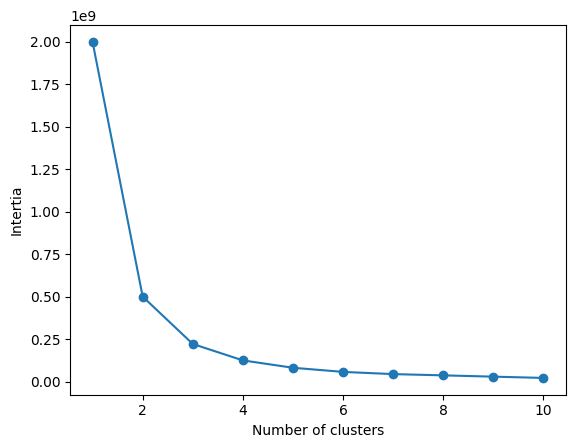

In [ ]:
plt.plot(range(1,11), intertia,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Intertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=10,init= 'k-means++',random_state=42)
kmeans.fit(customer_amount)

KMeans(n_clusters=10, random_state=42)

In [ ]:
lables = kmeans.labels_

In [ ]:
customer_amount['Cluster'] = lables

In [ ]:
customer_amount.head()

,CustomerID,TotalPrice,Cluster
0,12347.0,85.92,2
1,12350.0,17.70,2
2,12359.0,20.80,2
3,12360.0,17.70,2
4,12362.0,42.90,2
